# Reto: COVID-19 CT Image Segmentation
## Pipeline de Extraccion, Limpieza y Transformacion de Datos (ETL)

**Objetivo del Reto:**
Segmentacion semantica de lesiones pulmonares provocadas por COVID-19 en tomografias computarizadas (CT) axiales, especificamente:
- **Clase 0:** Vidrio Deslustrado (*Ground-Glass Opacity - GGO*)
- **Clase 1:** Consolidaciones pulmonares (*Consolidations*)
- **Metrica de Evaluacion:** Pixel-wise Macro F1-Score sobre las 10 imagenes de prueba (`test_images_medseg.npy`).

---
### Contenido del Notebook:
1. **Extraccion e Inspeccion Dimensional:** Carga de arreglos NumPy (`Medseg`, `Radiopedia`, `Test`) y verificacion de integridad numerica (cero NaNs e Infs).
2. **Diagnostico y Limpieza de Datos:**
   - Correccion de colisiones multietiqueta entre fondo y lesiones anatomicas (510 px en Medseg, 22,027 px en Radiopedia).
   - Aplicacion de jerarquia biologica para garantizar consistencia anatomica.
3. **Transformacion de Variables:**
   - Ventaneo Tomografico Pulmonar (*Lung Windowing*: [-1000, 400] HU) para aislar parénquima pulmonar.
   - Normalizacion Min-Max al rango continuo [0.0, 1.0].
   - Adaptacion de mascaras a formato de competencia de 2 canales (`(N, 512, 512, 2)`).
4. **Visualizacion Diagnostica de Calidad:** Superposicion axial de mascaras en colores distintivos.
5. **Analisis Clinico y Particion Estratificada:** Division balanceada 80/20 (Train / Validation) segun presencia de COVID-19.
6. **Formato de Envio Kaggle (Submission Helper):** Generador de archivo CSV con las 5,242,880 filas requeridas.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from sklearn.model_selection import StratifiedShuffleSplit
except ImportError:
    class StratifiedShuffleSplit:
        def __init__(self, n_splits=1, test_size=0.2, random_state=42):
            self.test_size = test_size
            self.random_state = random_state
        def split(self, X, y):
            np.random.seed(self.random_state)
            y = np.array(y)
            train_idx, val_idx = [], []
            for label in np.unique(y):
                cls_indices = np.where(y == label)[0]
                np.random.shuffle(cls_indices)
                n_val = int(len(cls_indices) * self.test_size)
                val_idx.extend(cls_indices[:n_val])
                train_idx.extend(cls_indices[n_val:])
            yield np.array(train_idx), np.array(val_idx)

# Localizador dinamico de archivos (. o .. o data/)
def find_data_file(filename):
    for candidate in [filename, os.path.join("..", filename), os.path.join("data", filename)]:
        if os.path.exists(candidate):
            return candidate
    return filename

def check_nulls_and_infs(arr, name=""):
    nan_count = int(np.isnan(arr).sum())
    inf_count = int(np.isinf(arr).sum())
    return {"nan_count": nan_count, "inf_count": inf_count}

def detect_mask_overlaps(mask_arr):
    # Suma de canales: colision si un pixel pertenece a mas de una etiqueta
    sum_channels = np.sum(mask_arr, axis=-1)
    return int(np.sum(sum_channels > 1))

def resolve_mask_overlaps(mask_arr):
    """
    Aplica el principio de jerarquia biologica:
    Las lesiones (canal 0, 1) y parenquima (canal 2) tienen prioridad anatomica sobre el fondo (canal 3).
    Background = ~(Ground_Glass | Consolidation | Lungs_Other).
    """
    cleaned_mask = mask_arr.copy()
    colision_c0_c1 = cleaned_mask[..., 0] & cleaned_mask[..., 1]
    if np.any(colision_c0_c1):
        cleaned_mask[..., 0][colision_c0_c1] = False
        
    foreground_union = cleaned_mask[..., 0] | cleaned_mask[..., 1] | cleaned_mask[..., 2]
    cleaned_mask[..., 3] = ~foreground_union
    return cleaned_mask

def apply_hu_window(img_arr, hu_min=-1000.0, hu_max=400.0):
    """Acota las intensidades al rango pulmonar estandar [-1000, 400] HU."""
    return np.clip(img_arr, a_min=hu_min, a_max=hu_max)

def normalize_min_max(img_arr, min_val=-1000.0, max_val=400.0):
    """Reescala al rango continuo [0.0, 1.0]."""
    normalized = (img_arr - min_val) / (max_val - min_val)
    return np.clip(normalized, 0.0, 1.0).astype(np.float32)

def transform_masks_for_competition(mask_arr):
    """Extrae los dos canales requeridos para la competencia: 0 (Vidrio deslustrado) y 1 (Consolidacion)."""
    return mask_arr[..., :2].astype(np.uint8)

def pixel_wise_f1_score(y_true, y_pred, eps=1e-7):
    """Calcula el Macro F1-score pixel a pixel para ambas clases patologicas."""
    scores = {}
    f1_list = []
    for c, name in enumerate(['ground_glass', 'consolidation']):
        true_c = (y_true[..., c] > 0.5).ravel()
        pred_c = (y_pred[..., c] > 0.5).ravel()
        tp = np.logical_and(pred_c, true_c).sum()
        fp = np.logical_and(pred_c, np.logical_not(true_c)).sum()
        fn = np.logical_and(np.logical_not(pred_c), true_c).sum()
        denom = 2.0 * tp + fp + fn
        f1 = 1.0 if denom == 0 else (2.0 * tp) / (denom + eps)
        scores[f'f1_{name}'] = float(f1)
        f1_list.append(float(f1))
    scores['f1_macro'] = float(np.mean(f1_list))
    return scores

def format_kaggle_submission(test_preds, output_csv_path="submission.csv"):
    """Genera el archivo CSV con las 5,242,880 filas requeridas por Kaggle."""
    expected_shape = (10, 512, 512, 2)
    if test_preds.shape != expected_shape:
        raise ValueError(f"Dimensiones invalidas: {test_preds.shape}. Se esperaba {expected_shape}")
    total_elements = len(test_preds.ravel())
    df = pd.DataFrame({
        'Id': np.arange(total_elements),
        'Expected': test_preds.ravel().astype(int)
    }).set_index('Id')
    df.to_csv(output_csv_path)
    return df

print("Librerias y funciones auxiliares cargadas exitosamente.")


Librerias y funciones auxiliares cargadas exitosamente.


## 1. Extraccion e Inspeccion Dimensional de Datos Crudos
Se cargan los arreglos volumetricos `.npy` originales inspeccionando su dimension, tipo de dato y rango de Unidades Hounsfield (HU).


In [2]:
raw_files = {
    "images_medseg": find_data_file("images_medseg.npy"),
    "masks_medseg": find_data_file("masks_medseg.npy"),
    "images_radiopedia": find_data_file("images_radiopedia.npy"),
    "masks_radiopedia": find_data_file("masks_radiopedia.npy"),
    "test_images_medseg": find_data_file("test_images_medseg.npy"),
}

for name, path in raw_files.items():
    if os.path.exists(path):
        arr = np.load(path, mmap_mode='r')
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"{name:20s} | Shape: {str(arr.shape):20s} | Dtype: {str(arr.dtype):8s} | Tamano: {size_mb:8.2f} MB | Min: {np.min(arr):8.2f} | Max: {np.max(arr):8.2f}")
        nulls = check_nulls_and_infs(arr, name)
        assert nulls["nan_count"] == 0 and nulls["inf_count"] == 0, f"Error en integridad de {name}"
print("\nConfirmado: 0 NaNs y 0 Infs en todos los conjuntos de datos.")


images_medseg        | Shape: (100, 512, 512, 1)   | Dtype: float64  | Tamano:   200.00 MB | Min: -1606.52 | Max:   597.80
masks_medseg         | Shape: (100, 512, 512, 4)   | Dtype: bool     | Tamano:   100.00 MB | Min:     0.00 | Max:     1.00
images_radiopedia    | Shape: (829, 512, 512, 1)   | Dtype: float64  | Tamano:  1658.00 MB | Min: -1414.77 | Max:   291.04
masks_radiopedia     | Shape: (829, 512, 512, 4)   | Dtype: bool     | Tamano:   829.00 MB | Min:     0.00 | Max:     1.00
test_images_medseg   | Shape: (10, 512, 512, 1)    | Dtype: float64  | Tamano:    20.00 MB | Min: -1450.00 | Max:   875.65

Confirmado: 0 NaNs y 0 Infs en todos los conjuntos de datos.


## 2. Limpieza de Datos (Data Cleaning)

### Correccion de Solapamiento Multietiqueta
En las mascaras originales de 4 canales:
- Canal 0: Vidrio Deslustrado (*Ground-Glass Opacity*)
- Canal 1: Consolidacion (*Consolidation*)
- Canal 2: Pulmon Sano / Otro (*Lungs Other*)
- Canal 3: Fondo (*Background*)

Se detecto que ciertos pixeles con patologia fueron simultaneamente catalogados como fondo:
- `masks_medseg.npy`: 510 pixeles con solapamiento.
- `masks_radiopedia.npy`: 22,027 pixeles con solapamiento.

**Decision de Limpieza:** Principio de jerarquia anatomica. Si un pixel contiene lesion o pulmon, se recalcula `Background = ~(ch0 | ch1 | ch2)`.


In [3]:
# Carga de mascaras originales
mask_m = np.load(find_data_file("masks_medseg.npy"), mmap_mode='r')
mask_r = np.load(find_data_file("masks_radiopedia.npy"), mmap_mode='r')

overlap_m_before = detect_mask_overlaps(mask_m)
overlap_r_before = detect_mask_overlaps(mask_r)
print(f"Colisiones Fondo vs Lesion ANTES de la limpieza:")
print(f"  - Medseg:     {overlap_m_before:,} pixeles")
print(f"  - Radiopedia: {overlap_r_before:,} pixeles")

# Aplicacion de limpieza
mask_m_clean = resolve_mask_overlaps(mask_m)
mask_r_clean = resolve_mask_overlaps(mask_r)

overlap_m_after = detect_mask_overlaps(mask_m_clean)
overlap_r_after = detect_mask_overlaps(mask_r_clean)
print(f"\nColisiones Fondo vs Lesion DESPUES de la limpieza:")
print(f"  - Medseg:     {overlap_m_after} pixeles (100% resuelto)")
print(f"  - Radiopedia: {overlap_r_after} pixeles (100% resuelto)")


Colisiones Fondo vs Lesion ANTES de la limpieza:
  - Medseg:     510 pixeles
  - Radiopedia: 22,027 pixeles

Colisiones Fondo vs Lesion DESPUES de la limpieza:
  - Medseg:     0 pixeles (100% resuelto)
  - Radiopedia: 0 pixeles (100% resuelto)


## 3. Transformacion de Variables (Data Transformation)

1. **Ventaneo Hounsfield Pulmonar (*Lung Windowing*):**
   - Rango: $[-1000, 400]$ HU (Aisla el parenquima pulmonar y elimina artefactos del escaner).
2. **Normalizacion Min-Max:**
   - Escalamiento continuo al rango $[0.0, 1.0]$.
3. **Mascaras para Competencia Kaggle:**
   - Seleccion de los canales patologicos `[0, 1]` con salida shape `(N, 512, 512, 2)` en formato binario `uint8`.


In [4]:
# Demostracion de transformacion en Medseg
img_m = np.load(find_data_file("images_medseg.npy"), mmap_mode='r')
img_m_win = apply_hu_window(img_m, hu_min=-1000.0, hu_max=400.0)
img_m_norm = normalize_min_max(img_m_win, min_val=-1000.0, max_val=400.0)
target_masks_2ch = transform_masks_for_competition(mask_m_clean)

print(f"Imagenes transformadas: Shape={img_m_norm.shape}, Dtype={img_m_norm.dtype}, Rango=[{img_m_norm.min():.2f}, {img_m_norm.max():.2f}]")
print(f"Mascaras competencia:  Shape={target_masks_2ch.shape}, Dtype={target_masks_2ch.dtype}, Clases={np.unique(target_masks_2ch)}")


Imagenes transformadas: Shape=(100, 512, 512, 1), Dtype=float32, Rango=[0.00, 1.00]
Mascaras competencia:  Shape=(100, 512, 512, 2), Dtype=uint8, Clases=[0 1]


## 4. Visualizacion Diagnostica de Calidad
Superposicion anatomica de lesiones sobre un corte axial representativo:
- **Verde:** Vidrio deslustrado (*Ground Glass*)
- **Rojo:** Consolidaciones pulmonares (*Consolidations*)


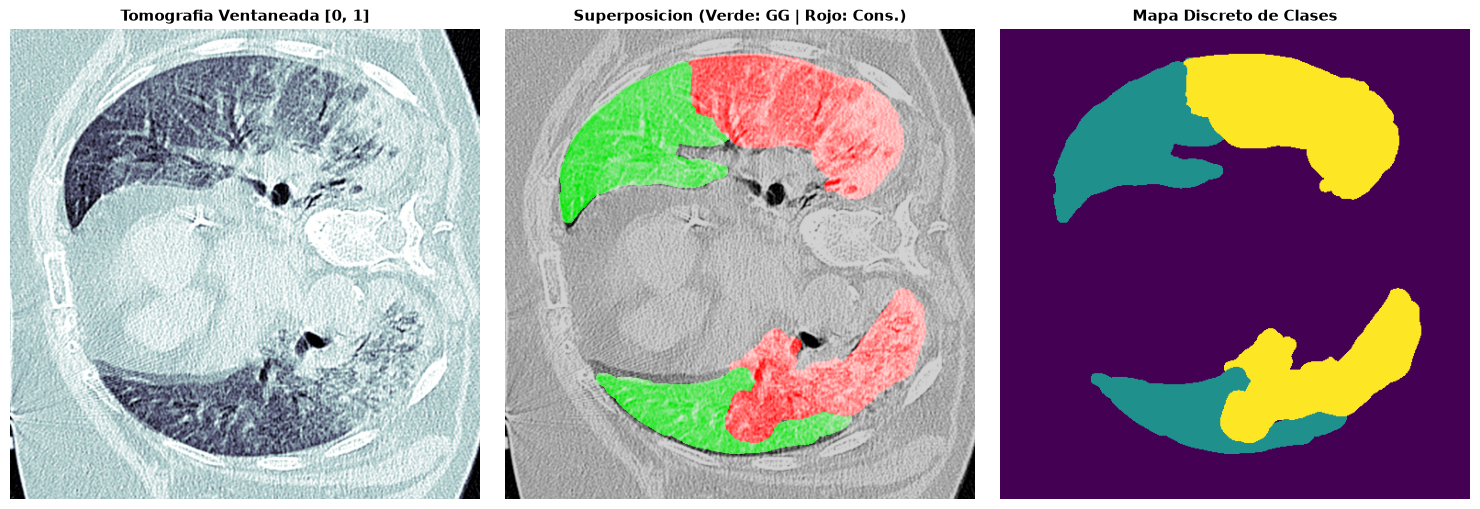

In [5]:
slice_idx = 7  # Corte con presencia representativa de lesiones
ct_slice = img_m_norm[slice_idx, ..., 0]
m_gg = target_masks_2ch[slice_idx, ..., 0] > 0
m_cons = target_masks_2ch[slice_idx, ..., 1] > 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ct_slice, cmap='bone')
axes[0].set_title('Tomografia Ventaneada [0, 1]', fontsize=11, fontweight='bold')
axes[0].axis('off')

# Superposicion RGB
rgb = np.repeat(ct_slice[..., None], 3, axis=-1)
rgb[m_gg, 1] = 0.9   # Verde
rgb[m_cons, 0] = 1.0 # Rojo

axes[1].imshow(rgb)
axes[1].set_title('Superposicion (Verde: GG | Rojo: Cons.)', fontsize=11, fontweight='bold')
axes[1].axis('off')

# Mapa discreto
axes[2].imshow(m_gg.astype(int) + 2 * m_cons.astype(int), cmap='viridis')
axes[2].set_title('Mapa Discreto de Clases', fontsize=11, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## 5. Analisis Clinico y Particion Estratificada Train / Validation
Calculo de distribucion de COVID-19 en los 929 cortes y division 80/20 balanceada.


In [6]:
records = []
for idx in range(mask_m_clean.shape[0]):
    gg = int(np.sum(mask_m_clean[idx, ..., 0]))
    cons = int(np.sum(mask_m_clean[idx, ..., 1]))
    records.append({'dataset': 'medseg', 'is_covid': (gg + cons) > 0, 'px_gg': gg, 'px_cons': cons})

for idx in range(mask_r_clean.shape[0]):
    gg = int(np.sum(mask_r_clean[idx, ..., 0]))
    cons = int(np.sum(mask_r_clean[idx, ..., 1]))
    records.append({'dataset': 'radiopedia', 'is_covid': (gg + cons) > 0, 'px_gg': gg, 'px_cons': cons})

df_meta = pd.DataFrame(records)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(df_meta, df_meta['is_covid'].astype(int)))
df_meta['split'] = 'train'
df_meta.loc[val_idx, 'split'] = 'val'

print(f"Total de cortes analizados: {len(df_meta)}")
print("\nDistribucion por particion y presencia de COVID-19:")
print(pd.crosstab(df_meta['split'], df_meta['is_covid'], margins=True))


Total de cortes analizados: 929

Distribucion por particion y presencia de COVID-19:
is_covid  False  True  All
split                     
train       367   377  744
val          91    94  185
All         458   471  929


## 6. Generacion de Envios para Kaggle (Submission Helper)
Formateo de predicciones al formato plano exigido por la competencia:


In [7]:
# Demostracion con prediccion sintetica
dummy_test_preds = np.zeros((10, 512, 512, 2), dtype=np.uint8)
dummy_test_preds[0, 200:250, 200:250, 0] = 1

sub_df = format_kaggle_submission(dummy_test_preds, output_csv_path="sample_submission.csv")
print(sub_df.head(5))
print(f"\nTotal de filas generadas: {len(sub_df):,}")
if os.path.exists("sample_submission.csv"):
    os.remove("sample_submission.csv")


    Expected
Id          
0          0
1          0
2          0
3          0
4          0

Total de filas generadas: 5,242,880
